In [1]:
import os, sys
os.environ['CUDA_VISIBLE_DEVICES'] = '2,'
# os.chdir("hmr4d/")
from pathlib import Path
import pickle as pkl
import json
from collections import defaultdict
from tqdm import tqdm
import zipfile
import shutil

import numpy as np
np.set_printoptions(suppress=True, precision=6)
import matplotlib.pyplot as plt
from einops import einsum
from PIL import Image
import lovely_tensors as lt
lt.monkey_patch()
import imageio.v3 as iio
from smplx.joint_names import SMPLH_JOINT_NAMES
SMPLH_JOINT_NAMES = np.array(SMPLH_JOINT_NAMES[:22] + ['left_hand', 'right_hand'])
import torch

from hmr4d.utils.body_model import BodyModelSMPLH, BodyModelSMPLX
from hmr4d.utils.eval.eval_utils import *
from hmr4d.utils.geo.hmr_cam import estimate_K, normalize_kp2d, create_camera_sensor
from hmr4d.utils.geo_transform import compute_cam_angvel, apply_T_on_points, move_to_start_point_face_z
from hmr4d.utils.vis.renderer import Renderer, get_global_cameras_static, get_ground_params_from_points
from hmr4d.utils.video_io_utils import get_writer
from hmr4d.utils.vis.cv2_utils import draw_bbx_xys_on_image_batch, draw_kpts_with_conf_batch

device = 'cuda'

In [2]:
smpl = BodyModelSMPLH(
    model_path="inputs/checkpoints/body_models", model_type="smpl",
    gender="neutral", num_betas=10, create_body_pose=False, 
    create_betas=False, create_global_orient=False, create_transl=False,
).to(device)
smpl_male = BodyModelSMPLH(
    model_path="inputs/checkpoints/body_models", model_type="smpl",
    gender="male", num_betas=10, create_body_pose=False, 
    create_betas=False, create_global_orient=False, create_transl=False,
).to(device)
smpl_female = BodyModelSMPLH(
    model_path="inputs/checkpoints/body_models", model_type="smpl",
    gender="female", num_betas=10, create_body_pose=False, 
    create_betas=False, create_global_orient=False, create_transl=False,
).to(device)

smplx = BodyModelSMPLX(
    model_path="inputs/checkpoints/body_models", model_type="smplx",
    gender="neutral", num_pca_comps=12, flat_hand_mean=False,
).to(device)
smplx_male = BodyModelSMPLX(
    model_path="inputs/checkpoints/body_models", model_type="smplx",
    gender="male", num_pca_comps=12, flat_hand_mean=False,
).to(device)
smplx_female = BodyModelSMPLX(
    model_path="inputs/checkpoints/body_models", model_type="smplx",
    gender="female", num_pca_comps=12, flat_hand_mean=False,
).to(device)

smplx2smpl = torch.load("hmr4d/utils/body_model/smplx2smpl_sparse.pt").to(device)
faces_smpl = torch.from_numpy((smpl.faces).astype("int")).unsqueeze(0).to(device)
faces_smplx = torch.from_numpy((smplx.faces).astype("int")).unsqueeze(0).to(device)
J_regressor = torch.load("hmr4d/utils/body_model/smpl_neutral_J_regressor.pt").to(device)

/tmp/ipykernel_3234561/2456836189.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  smplx2smpl = torch.load("hmr4d/utils/body_model/smplx2smpl_sparse.pt").to(device)
/tmp

In [ ]:
### 3DPW 

In [ ]:
dataset_dir = Path("samples/debug/3dpw_debug")
output_dir = Path("outputs/debug/3dpw_debug")
root_dir = Path("inputs/3DPW/origin/imageFiles")
output_dir.mkdir(exist_ok=True, parents=True)
# items = sorted(list(set(["_".join(x.stem.split("_")[:-1]) for x in output_dir.glob("*_batch.pt")])))

# vid = 'P1_14_outdoor_climb'
# vid = 'P3_32_outdoor_soccer_warmup_a'
vid = 'downtown_runForBus_01_0'
# vid = list(pa_outlier_dict.keys())[24]
category, vid_name = vid.split('_')[0], '_'.join(vid.split('_')[1:])

batch = torch.load(dataset_dir / f"{vid}_batch.pt")
vertice_sets = torch.load(dataset_dir / f"{vid}_pred_target.pt")
metrics = pkl.loads((dataset_dir / f"{vid}_results.pkl").read_bytes())
print("\n".join(f"{k}: {v.mean().item()}" for k,v in metrics.items()))
outliers = json.loads(((dataset_dir / f"{vid}_outliers.json")).read_text())
print(sorted([x['frame'] for x in outliers]))
# topk_outlier_frames(metrics, ['accel'])
plot_img = Image.open(dataset_dir / f"{vid}_metrics.png")
plot_img.resize((512, 512))

In [ ]:
detect_peak_intervals_thresholded(metrics['pve'], peak_threshold=100)

In [ ]:
start_i_2, end_i_2 = 405, 605 #len(batch['kp2d'])
video_dir = root_dir / "_".join(vid.split('_')[:-1])
K_fullimg = batch["K_fullimg"][0]

width, height = int(K_fullimg[0,2].item() * 2), int(K_fullimg[1,2].item() * 2)
renderer_c = Renderer(width, height, device="cuda", faces=smpl.faces, K=K_fullimg)

pred_gb_verts, pred_gb_joints = move_to_start_point_face_z(vertice_sets['pred_verts_glob'][start_i_2:end_i_2].to(device), J_regressor)
target_c_verts = vertice_sets['target_verts'][start_i_2:end_i_2].to(device)
pred_c_verts = vertice_sets['pred_verts'][start_i_2:end_i_2].to(device)
target_gb_verts, target_gb_joints = move_to_start_point_face_z(vertice_sets['target_verts_glob'][start_i_2:end_i_2].to(device), J_regressor)

global_R, global_T, global_lights = get_global_cameras_static(
    pred_gb_joints.cpu(), beta=4.0, cam_height_degree=20, target_center_height=1.0
)
_, _, K = create_camera_sensor(width, height, 24)
renderer_g = Renderer(width, height, device="cuda", faces=smpl.faces, K=K)
# -- render mesh -- #
scale, cx, cz = get_ground_params_from_points(pred_gb_joints[:, 0], pred_gb_verts)
renderer_g.set_ground(scale * 1.5, cx, cz)
gb_cameras = renderer_g.create_camera(global_R[0], global_T[0])

In [ ]:
def get_frame(i):
    origin_frame = Image.fromarray(iio.imread(video_dir / f"image_{i:05d}.jpg"))
    v_w, v_h = origin_frame.size

    origin_frame_1 = np.asarray(origin_frame).copy()
    origin_frame_1 = draw_bbx_xys_on_image_batch(batch['bbx_xys'][i:i+1], [origin_frame_1], thickness=8)[0]
    origin_frame_1 = draw_kpts_with_conf_batch(
        [origin_frame_1[..., ::-1]], batch['kp2d'][i:i+1, ..., :2], 
        torch.clamp((batch['kp2d'][i:i+1, ...,  2] - 0.5) * 2, 0.0, 1.0), 
        thickness=8)[0][...,::-1]

    origin_frame_2 = np.asarray(origin_frame).copy()
    result_frame = renderer_c.render_mesh(
        target_c_verts[i-start_i_2],
        background=np.array(origin_frame_2), 
        colors=[0.8, 0.8, 0.8])
    result_frame = renderer_c.render_mesh(
        pred_c_verts[i-start_i_2],
        background=result_frame, 
        colors=[0.7, 0.7, 0.9])

    # gb_verts = torch.cat([pred_gb_verts[[i-start_i_2]], target_gb_verts[[i-start_i_2]]])
    # gb_colors = torch.tensor([[0.7, 0.7, 0.9], [0.8, 0.8, 0.8]], device=device)
    # global_result_frame = renderer_g.render_with_ground(
    #     gb_verts, colors=gb_colors, 
    #     cameras=gb_cameras, lights=global_lights)
        
    final_frame = Image.new('RGB', (int(v_w * 2.0), v_h))
    final_frame.paste(Image.fromarray(origin_frame_1), (0, 0))
    final_frame.paste(Image.fromarray(result_frame), (v_w, 0))
    # final_frame.paste(Image.fromarray(global_result_frame), (int(v_w*2), 0))
    return final_frame

i = 475
perjoint_jpe = compute_camcoord_perjoint_metrics(vertice_sets)['mpjpe'][i]
mpjpe = perjoint_jpe.mean(-1).item()
print(mpjpe)
print(perjoint_jpe)
print(np.array(SMPLH_JOINT_NAMES)[np.where(perjoint_jpe > mpjpe*2)[0]])

final_frame = get_frame(i)
final_frame

In [ ]:
start_i, end_i = start_i_2, end_i_2
out_video_dir = output_dir / f"gvhmr-{vid}_output_{start_i}_{end_i}.mp4"

writer = get_writer(out_video_dir, fps=10, crf=23)
for i in tqdm(range(start_i, end_i)):
    final_frame = get_frame(i)
    # final_frame.save(f"outputs/emdb_debug/{vid}_frame_{i}.png")
    writer.write_frame(np.array(final_frame))
writer.close()

out_video_dir = dataset_dir / f"{vid}-{start_i}-{end_i}.mp4"
writer = get_writer(out_video_dir, fps=30, crf=23)
for i in range(start_i, end_i):
    img_dir = video_dir / f"image_{i:05d}.jpg"
    writer.write_frame(np.array(Image.open(img_dir)))
writer.close()

In [ ]:
### EMDB

/tmp/ipykernel_3234561/1349905511.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  batch = torch.load(dataset_dir / f"{vid}_batch.pt")
/tmp/ipykernel_3234561/1349905511.

pa_mpjpe: 49.217035842626586
mpjpe: 95.82769088894518
pve: 105.68972400585602
wa2_mpjpe: 139.29685260608363
waa_mpjpe: 93.50204609081577
rte: 1.322171473287182
[865, 866, 867, 868, 869, 870, 871, 874, 920, 921, 922, 923, 924, 924, 925, 995, 996, 997, 998, 999]


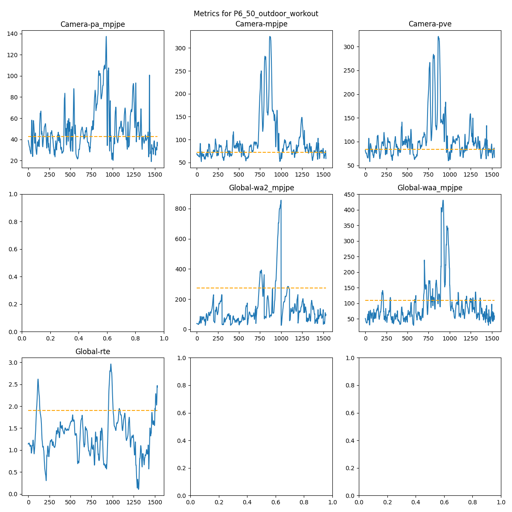

In [10]:
dataset_dir = Path("samples/debug/emdb_debug")
output_dir = Path("outputs/debug/emdb_debug/")
root_dir = Path("/data/datasets/emdb/")
prompthmr_output_dir = Path("/home/guangyu/patrick/PromptHMR/outputs/debug/emdb_debug")

# vid = 'P1_14_outdoor_climb'
# vid = 'P3_32_outdoor_soccer_warmup_a'
vid = 'P6_50_outdoor_workout'
# vid = list(pa_outlier_dict.keys())[24]
category, vid_name = vid.split('_')[0], '_'.join(vid.split('_')[1:])

batch = torch.load(dataset_dir / f"{vid}_batch.pt")
vertice_sets = torch.load(dataset_dir / f"{vid}_pred_target.pt")
metrics = pkl.loads((dataset_dir / f"{vid}_results.pkl").read_bytes())
print("\n".join(f"{k}: {v.mean().item()}" for k,v in metrics.items()))
outliers = json.loads(((dataset_dir / f"{vid}_outliers.json")).read_text())
print(sorted([x['frame'] for x in outliers]))
# topk_outlier_frames(metrics, ['accel'])
plot_img = Image.open(dataset_dir / f"{vid}_metrics.png")
plot_img.resize((512, 512))

In [11]:
# topk_outlier_frames(metrics, ['waa_mpjpe'])
detect_peak_intervals_thresholded(metrics['mpjpe'], peak_threshold=110) # 568~604 / 506 ~ 523

([{'start_idx': 410,
   'peak_idx': 433,
   'end_idx': 443,
   'peak_val': 114.91197204589844,
   'smoothed_peak_val': 114.70742886772283,
   'prominence': 60.60886330593458},
  {'start_idx': 721,
   'peak_idx': 764,
   'end_idx': 783,
   'peak_val': 249.93975830078125,
   'smoothed_peak_val': 250.19167230068194,
   'prominence': 131.77325697323147},
  {'start_idx': 783,
   'peak_idx': 807,
   'end_idx': 813,
   'peak_val': 279.9870910644531,
   'smoothed_peak_val': 280.4797342651661,
   'prominence': 126.37801981750385},
  {'start_idx': 843,
   'peak_idx': 866,
   'end_idx': 897,
   'peak_val': 325.0578308105469,
   'smoothed_peak_val': 325.7558260830977,
   'prominence': 271.8245508153965},
  {'start_idx': 897,
   'peak_idx': 899,
   'end_idx': 918,
   'peak_val': 162.61422729492188,
   'smoothed_peak_val': 163.25347221036668,
   'prominence': 0.5090334876711893},
  {'start_idx': 918,
   'peak_idx': 924,
   'end_idx': 937,
   'peak_val': 154.57948303222656,
   'smoothed_peak_val': 15

In [12]:
start_i_2, end_i_2 = 720, 970 #len(batch['kp2d'])
video_dir = root_dir / f"{category}/{vid_name}/{vid}_video.mp4"
width_height = (1440, 1920) if vid != "P0_09_outdoor_walk" else (720, 960)
K_fullimg = estimate_K(*width_height)

width, height = int(K_fullimg[0,2].item() * 2), int(K_fullimg[1,2].item() * 2)
renderer_c = Renderer(width, height, device="cuda", faces=smpl.faces, K=K_fullimg)

pred_gb_verts, pred_gb_joints = move_to_start_point_face_z(vertice_sets['pred_verts_glob'][start_i_2:end_i_2].to(device), J_regressor)
pred_c_verts = vertice_sets['pred_verts'][start_i_2:end_i_2].to(device)
# vertice_sets_prompt = torch.load(prompthmr_output_dir / f"{vid}-{start_i_2}-{end_i_2}_pred_target.pt")
# pred_c_verts = vertice_sets_prompt['pred_verts'][0:end_i_2-start_i_2].to(device)
# pred_gb_verts, pred_gb_joints = move_to_start_point_face_z(vertice_sets_prompt['pred_verts_glob'][0:end_i_2-start_i_2].to(device), J_regressor)
target_gb_verts, target_gb_joints = move_to_start_point_face_z(vertice_sets['target_verts_glob'][start_i_2:end_i_2].to(device), J_regressor)

global_R, global_T, global_lights = get_global_cameras_static(
    pred_gb_joints.cpu(), beta=4.0, cam_height_degree=20, target_center_height=1.0
)
_, _, K = create_camera_sensor(width, height, 24)
renderer_g = Renderer(width, height, device="cuda", faces=smpl.faces, K=K)
# -- render mesh -- #
scale, cx, cz = get_ground_params_from_points(pred_gb_joints[:, 0], pred_gb_verts)
renderer_g.set_ground(scale * 1.5, cx, cz)
gb_cameras = renderer_g.create_camera(global_R[0], global_T[0])

243.3361053466797
[ 54.00889    6.289441   6.289441 127.74135  230.17442  208.96625
 222.3496   376.46155  441.9691   235.1833   399.2069   476.53427
 261.60498  249.04184  250.64465  260.6722   261.79355  233.71028
 293.03162  194.77641  257.14258  232.99388  272.71967  286.76    ]
[]


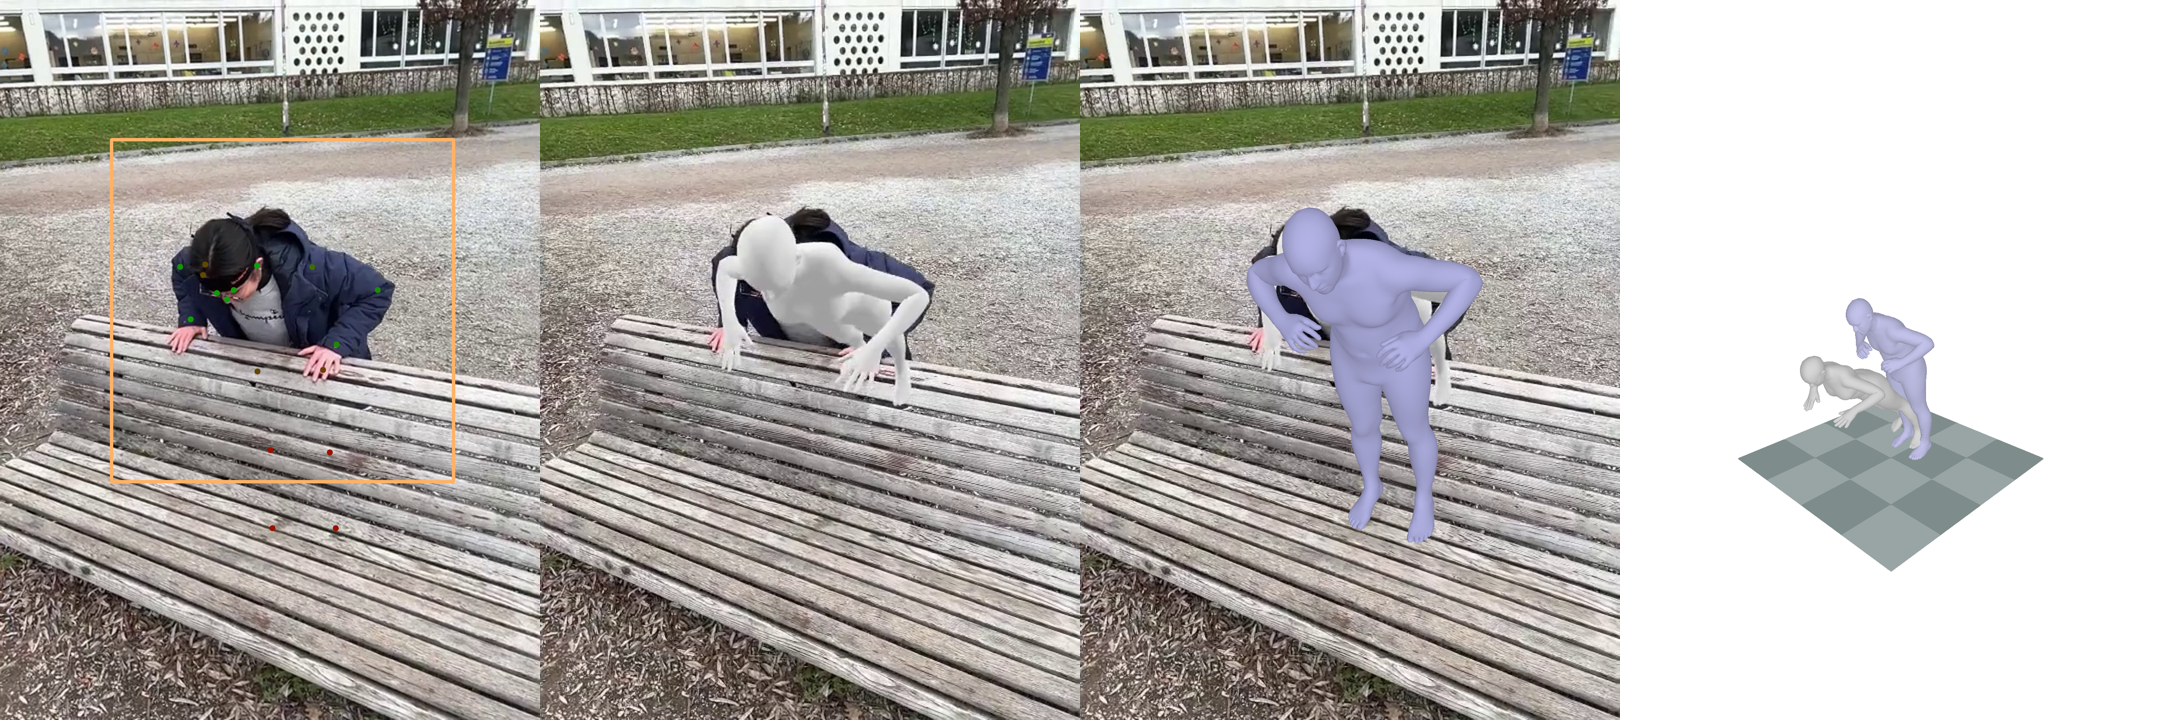

In [13]:
def get_frame(i):
    combine_frame = Image.fromarray(iio.imread(video_dir, index=i))
    v_w, v_h = combine_frame.size

    origin_frame_1 = np.asarray(combine_frame.crop((0, 0, v_w//2, v_h)).resize((width, height)))
    origin_frame_1 = draw_bbx_xys_on_image_batch(batch['bbx_xys'][i:i+1], [origin_frame_1], thickness=8)[0]
    origin_frame_1 = draw_kpts_with_conf_batch(
        [origin_frame_1[..., ::-1]], 
        batch['kp2d'][i:i+1, ..., :2], 
        torch.clamp((batch['kp2d'][i:i+1, ...,  2] - 0.5) * 2, 0.0, 1.0), 
        thickness=8)[0][...,::-1]

    origin_frame_2 = combine_frame.crop((v_w//2, 0, v_w, v_h)).resize((width, height))
    result_frame = renderer_c.render_mesh(
        pred_c_verts[i-start_i_2],
        background=np.array(origin_frame_2), 
        colors=[0.7, 0.7, 0.9])

    gb_verts = torch.cat([pred_gb_verts[[i-start_i_2]], target_gb_verts[[i-start_i_2]]])
    gb_colors = torch.tensor([[0.7, 0.7, 0.9], [0.8, 0.8, 0.8]], device=device)
    global_result_frame = renderer_g.render_with_ground(gb_verts, colors=gb_colors, cameras=gb_cameras, lights=global_lights)
        
    final_frame = Image.new('RGB', (int(v_w * 2.0), v_h))
    final_frame.paste(Image.fromarray(origin_frame_1).resize((v_w//2, v_h)), (0, 0))
    final_frame.paste(origin_frame_2.resize((v_w//2, v_h)), (v_w//2, 0))
    final_frame.paste(Image.fromarray(result_frame).resize((v_w//2, v_h)), (v_w, 0))
    final_frame.paste(Image.fromarray(global_result_frame).resize((v_w//2, v_h)), (int(v_w*3//2), 0))
    return final_frame

i = start_i_2+40

perjoint_jpe = compute_camcoord_perjoint_metrics(vertice_sets)['mpjpe'][i]
mpjpe = perjoint_jpe.mean(-1).item()
print(mpjpe)
print(perjoint_jpe)
print(np.array(SMPLH_JOINT_NAMES)[np.where(perjoint_jpe > mpjpe*2)[0]])

final_frame = get_frame(i)
final_frame

In [ ]:
start_i, end_i = start_i_2, end_i_2
out_video_dir = output_dir / f"{vid}_output_{start_i}_{end_i}.mp4"

writer = get_writer(out_video_dir, fps=10, crf=23)
for i in tqdm(range(start_i, end_i)):
    final_frame = get_frame(i)
    # final_frame.save(f"outputs/emdb_debug/{vid}_frame_{i}.png")
    writer.write_frame(np.array(final_frame))
writer.close()

out_video_dir = dataset_dir / f"{vid}-{start_i}-{end_i}.mp4"
target_zip = zipfile.ZipFile(root_dir / f"_{category}.zip")
writer = get_writer(out_video_dir, fps=30, crf=23)
for i in range(start_i, end_i):
    target_name = f"{category}/{vid_name}/images/{i:05d}.jpg"
    target_zip.extract(target_name, path='outputs/')
    shutil.move('outputs/' + target_name, 'tmp.png')
    writer.write_frame(np.array(Image.open("tmp.png")))
writer.close()
target_zip.close()

100%|██████████| 250/250 [05:45<00:00,  1.38s/it]


In [ ]:
# metrics_dict = {k.stem.replace("_results", ""): pkl.loads(k.read_bytes()) for k in dataset_dir.glob("*_results.pkl")}
# pa_mpjpe_list = [i for k in metrics_dict for i in metrics_dict[k]['pa_mpjpe']]
# pa_limit = np.mean(pa_mpjpe_list) + 2.5*np.std(pa_mpjpe_list)
# print(pa_limit)

# # pa_outlier_dict = defaultdict(list)
# # for json_dir in dataset_dir.glob("*_outliers.json"):
# #     outliers = json.loads(json_dir.read_text())
# #     for outlier in outliers:
# #         for reason in outlier['reasons']:
# #             if reason['metric'] == 'pa_mpjpe' and reason['value'] >= pa_limit:
# #                 pa_outlier_dict[json_dir.stem.replace("_outliers", "")].append(outlier)
# # print({k: len(v) for k,v in pa_outlier_dict.items()})

# smpl_params_tmp = vertice_sets['pred_smpl_params_global'].copy()
# smpl_params_gt = batch['smpl_params'].copy()
# # smpl_params_tmp['body_pose'] = torch.zeros_like(smpl_params_tmp['body_pose'])
# # smpl_params_tmp['transl'] = torch.zeros_like(smpl_params_tmp['transl'])
# # smpl_params_tmp['global_orient'] = torch.zeros_like(smpl_params_tmp['global_orient'])
# smpl_result_tmp = smplx(**{k:v.to(device) for k,v in smpl_params_tmp.items()})

# # tmp = np.array([
# #     (x[..., 1].max(dim=0).values - x[..., 1].min(dim=0).values).item() 
# #     for x in smpl_result_tmp.vertices]
# # )
# tmp = smpl_params_tmp['transl'][..., 0].cpu().numpy()
# tmp2 = smpl_params_gt['transl'][..., 0].cpu().numpy()

# plt.plot(np.array([tmp, tmp2]).T)


# batch['kp2d'][i].numpy()

# image1 = Image.open("tmp.png")
# canvas = Image.new("RGB", image1.size, (127, 127, 127))
# canvas.paste(image1.crop((0, 0, 1440, 1000)), (0, 0))
# canvas.save("tmp_img.png")
# mask = Image.new("L", image1.size, 255)
# mask.paste(Image.new("L", (1440, 1000), 0), (0, 0))
# mask.save("tmp_mask.png")